In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
})

### 0_create_arrow_files.R

In [2]:
opts = list()

# Options
opts$samples <- c(
  # "E7.5_rep1",
  # "E7.5_rep2",
  # "E8.0_rep1",
  # "E8.0_rep2",
  # "E8.5_rep1",
  # "E8.5_rep2",
  "E8.75_rep1"
)

# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation'
io$output.directory <- file.path(io$basedir,"processed/atac/archR")
setwd(io$output.directory)

io$fragment_files <- opts$samples %>% 
  map_chr(~ sprintf("%s/%s/atac_fragments.tsv.gz",io$basedir,.)) %>%
  set_names(opts$samples)

# Options
opts$min.fragments <- 2500
opts$filterTSS.score <- 3

# ArchR options
addArchRThreads(threads = 8) 
addArchRGenome("mm10")

Setting default number of Parallel threads to 8.

Setting default genome to Mm10.



In [3]:
ArrowFiles <- createArrowFiles(
  inputFiles = io$fragment_files,
  sampleNames = names(io$fragment_files),
  outputNames = names(io$fragment_files),
  addTileMat = FALSE,
  addGeneScoreMat = TRUE,
  excludeChr = c("chrM", "chrY"),

  # QC metrics
  minFrags = opts$min.fragments,  # The minimum number of fragments per cell
  minTSS = opts$filterTSS.score   # The minimum TSS enrichment score per cell
)

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

ArchR logging to : ArchRLogs/ArchR-createArrows-162132ab5371b-Date-2021-11-24_Time-10-57-52.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2021-11-24 10:57:52 : Batch Execution w/ safelapply!, 0 mins elapsed.

(E8.75_rep1 : 1 of 1) Checking if completed file exists!

2021-11-24 10:57:52 : (E8.75_rep1 : 1 of 1) Arrow Exists! Marking as completed since force = FALSE!, 0.003 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-createArrows-162132ab5371b-Date-2021-11-24_Time-10-57-52.log



#### 1_create_archR_project.R

In [4]:
# I/O
io$output.directory <- file.path(io$basedir,"processed/atac/archR")

io$arrowFiles <- c(
  # "E7.5_rep1" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E7.5_rep1.arrow"),
  # "E7.5_rep2" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E7.5_rep2.arrow"),
  # "E8.0_rep1" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E8.0_rep1.arrow"),
  # "E8.0_rep2" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E8.0_rep2.arrow"),
  # "E8.5_rep1" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E8.5_rep1.arrow"),
  # "E8.5_rep2" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E8.5_rep2.arrow"),
  "E8.75_rep1" = file.path(io$basedir,"processed/atac/archR/E8.75_rep1.arrow")
 # "E8.75_rep2" = file.path(io$basedir,"processed/atac/archR/ArrowFiles/E8.75_rep2.arrow")
)

# ArchR options
#addArchRThreads(threads = 2) 
addArchRGenome("mm10")

############################
## create an ArchRProject ##
############################

ArchRProject <- ArchRProject(
  ArrowFiles = io$arrowFiles, 
  outputDirectory = io$output.directory,
  copyArrows = FALSE
)

##########
## Save ##
##########

saveArchRProject(ArchRProject)

Setting default genome to Mm10.

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

Validating Arrows...

Getting SampleNames...

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \   

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/processed/atac/archR 
samples(1): E8.75_rep1
sampleColData names(1): ArrowFiles
cellColData names(13): Sample TSSEnrichment ... nDiFrags BlacklistRatio
numberOfCells(1): 3247
medianTSS(1): 17.811
medianFrags(1): 43473

#### 2_create_archR_metadata.R

In [10]:
source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [12]:
### Edited because RNA metadata not available

# I/O
#io$metadata <- paste0(io$basedir,"/results/rna/doublets/sample_metadata_after_doublets.txt.gz")
io$metadata.out <- paste0(io$archR.directory,"sample_metadata.txt.gz")

###################
## Load metadata ##
###################

# sample_metadata <- fread(io$metadata) %>%
#   .[,c("cell", "sample", "barcode", "stage", "nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA", "pass_rnaQC", "celltype.mapped", "celltype.score", "closest.cell","hybrid_score", "doublet_call")]
#        # "TSSEnrichment_atac", "ReadsInTSS_atac", "PromoterRatio_atac", "NucleosomeRatio_atac", "nFrags_atac", "BlacklistRatio_atac", "pass_atacQC")

########################
## Load ArchR project ##
########################

source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")

######################
## Load ArchR stats ##
######################
  
# fetch archR's metadata
# note that QC is done later in the QC/qc.R script
archR_metadata <- getCellColData(ArchRProject) %>%
  as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
  .[,c("cell", "TSSEnrichment", "ReadsInTSS", "PromoterRatio", "NucleosomeRatio", "nFrags",  "BlacklistRatio")]# %>%
  # setnames("Sample","sample") %>%
  # .[,cell:=stringr::str_replace_all(cell,"#","_")] %>%
  # .[,sample:=strsplit(cell,"#") %>% map_chr(1)] %>%
  # .[,barcode:=strsplit(cell,"#") %>% map_chr(2)]

cols.to.rename <- c("TSSEnrichment","ReadsInTSS","PromoterRatio","NucleosomeRatio","nFrags","BlacklistRatio")
idx.cols.to.rename <- which(colnames(archR_metadata)%in%cols.to.rename)
colnames(archR_metadata)[idx.cols.to.rename] <- paste0(colnames(archR_metadata)[idx.cols.to.rename], "_atac")

###########
## Merge ##
###########

# sample_metadata_all <- sample_metadata %>% 
#   merge(archR_metadata,by="cell", all=TRUE) 

sample_metadata_all = archR_metadata

# Fill missing entries
sample_metadata_all = sample_metadata_all %>%
  .[,sample:=strsplit(cell,"#") %>% map_chr(1)] %>%
  .[,barcode:=strsplit(cell,"#") %>% map_chr(2)] %>%
  .[,stage:=strsplit(sample,"_") %>% map_chr(1)]

# sanity checks
table(sample_metadata_all$stage)
table(sample_metadata_all$sample)
stopifnot(all(!is.na(sample_metadata_all$sample)))
stopifnot(all(!is.na(sample_metadata_all$barcode)))
stopifnot(all(!is.na(sample_metadata_all$stage)))

#############################
## Update ArchR's metadata ##
#############################

metadata.to.archR <- sample_metadata_all %>% 
  .[cell%in%rownames(ArchRProject)] %>% setkey(cell) %>% .[rownames(ArchRProject)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(metadata.to.archR$TSSEnrichment_atac == getCellColData(ArchRProject, "TSSEnrichment")[[1]]))

for (i in colnames(metadata.to.archR)) {
  ArchRProject <- addCellColData(
    ArchRProject,
    data = metadata.to.archR[[i]], 
    name = i,
    cells = rownames(metadata.to.archR),
    force = TRUE
  )
}

head(getCellColData(ArchRProject))

##########
## Save ##
##########
io$metadata.out <- paste0(io$archR.directory,"sample_metadata.txt.gz")
fwrite(sample_metadata_all, io$metadata.out, sep="\t", na="NA", quote=F)

saveArchRProject(ArchRProject)

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__


E8.75 
 3247 


E8.75_rep1 
      3247 

DataFrame with 6 rows and 22 columns
                                   Sample TSSEnrichment ReadsInTSS
                              <character>     <numeric>  <numeric>
E8.75_rep1#AAACCGAAGGAGCATA-1  E8.75_rep1        14.404      10809
E8.75_rep1#CCTATAGCATCTTGAG-1  E8.75_rep1        16.864      12970
E8.75_rep1#CGAGCGAAGCTCCTAC-1  E8.75_rep1        14.881      11272
E8.75_rep1#CATTTGTTCCCGTTGT-1  E8.75_rep1        14.549      10896
E8.75_rep1#AGCTACGTCTATCGCC-1  E8.75_rep1        15.839      11086
E8.75_rep1#AATATCCCATGTGGGA-1  E8.75_rep1        12.528      10806
                              ReadsInPromoter ReadsInBlacklist PromoterRatio
                                    <numeric>        <numeric>     <numeric>
E8.75_rep1#AAACCGAAGGAGCATA-1           41262             3266      0.206405
E8.75_rep1#CCTATAGCATCTTGAG-1           47358             3145      0.236925
E8.75_rep1#CGAGCGAAGCTCCTAC-1           41441             3428      0.207392
E8.75_rep1#CATTTGTTCCCGTTGT-1           42

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/processed/atac/archR 
samples(1): E8.75_rep1
sampleColData names(1): ArrowFiles
cellColData names(22): Sample TSSEnrichment ... barcode stage
numberOfCells(1): 3247
medianTSS(1): 17.811
medianFrags(1): 43473

#### 3_qc.R

In [13]:
########################
## Load ArchR project ##
########################

# here::i_am("atac/archR/processing/3_qc.R")
# source(here::here("settings.R"))

#####################
## Define settings ##
#####################

# I/O
# io$metadata <- paste0(io$basedir,"/processed/atac/archR/sample_metadata_after_archR.txt.gz")
io$outdir <- file.path(io$basedir,"results/atac/archR/qc")

# Options
opts$samples <- c(
#   "E7.5_rep1",
#   "E7.5_rep2",
#   "E8.0_rep1",
#   "E8.0_rep2",
#   "E8.5_rep1",
#   "E8.5_rep2"
    "E8.75_rep1"
)

# QC thresholds
opts$min.TSSEnrichment <- 9
opts$min.log_nFrags <- 11.75 # 2**11.75 ~ 3500
# opts$min.log_nFrags <- 11
opts$max.BlacklistRatio <- 0.05

opts$test <- TRUE


########################
## Load cell metadata ##
########################
io$metadata <- paste0(io$archR.directory,"sample_metadata.txt.gz")

sample_metadata <- fread(io$metadata)

########################
## Load ArchR project ##
########################

source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")

# Subset
# ArchRProject <- ArchRProject[sample_metadata[pass_atacQC==TRUE,cell]

#############
## Call QC ##
#############

 sample_metadata %>%
   .[,pass_atacQC:=TSSEnrichment_atac>=opts$min.TSSEnrichment & log2(nFrags_atac)>=opts$min.log_nFrags & BlacklistRatio_atac<=opts$max.BlacklistRatio] %>%
   .[is.na(pass_atacQC),pass_atacQC:=FALSE]

# print(sample_metadata[,mean(pass_atacQC,na.rm=T),by="sample"])
# print(sample_metadata[,mean(is.na(nFrags_atac)),by="sample"])

# Save
# outfile <- paste0(io$outdir,"/sample_metadata_after_qc.txt.gz")
# fwrite(sample_metadata, outfile, quote=F, na="NA", sep="\t")


##################
## Subset ArchR ##
##################

if (opts$test) {
  
  # Subset cells for faster computations
  cells.to.use <- split(ArchRProject$cellNames,ArchRProject$sample) %>% map(~ head(.,n=1000)) %>% unlist
  
  # Subset features for faster computations
  tss.granges <- getTSS(ArchRProject)
  tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]
  ArchRProject <- ArchRProject[cells.to.use,]
}

#########################
## Plot TSS Enrichment ##
#########################

tss.granges <- getTSS(ArchRProject)
if (opts$test) tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]

# to.plot.tss <- plotTSSEnrichment(
#   ArchRProj = ArchRProject, 
#   groupBy = "Sample", 
#   returnDF = TRUE,
#   TSS = tss.granges
# ) %>% 
#   as.data.table %>% setnames("group","sample") %>% 
#   melt(id.vars=c("sample","x"))

to.plot.tss <- opts$samples %>% map(function(i) {
  plotTSSEnrichment(
    ArchRProj = ArchRProject[ArchRProject$Sample==i,], 
    groupBy = "Sample", 
    returnDF = TRUE,
    TSS = tss.granges
  ) %>% as.data.table %>% return
}) %>% rbindlist %>% 
  setnames("group","sample") %>% 
  melt(id.vars=c("sample","x"))

# For some reason this doesnt work........
fwrite(to.plot.tss, sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir))

to.plot.tss <- fread(sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(value=mean(value)), by = c("stage","x","variable")]

p <- ggline(to.plot.tss[variable=="normValue"], x="x", y="value", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  #scale_colour_manual(values=opts$stage.colors) +
  # scale_x_continuous(breaks=seq(-2000,2000,1000)) +
  labs(x="Distance from TSS (bp)", y="TSS enrichment (normalised)") +
  theme(
    axis.text = element_text(size=rel(0.5)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "none",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_TSSenrichment.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

#####################################
## Plot Fragment size distribution ##
#####################################

to.plot.fragmentsize <- plotFragmentSizes(ArchRProject, groupBy = "Sample", returnDF=T) %>% 
  as.data.table %>% setnames("group","sample")
fwrite(to.plot.fragmentsize, sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir))

# to.plot <- to.plot.fragmentsize %>% .[variable=="fragmentPercent"] %>% .[,fragmentSize:=1:.N,by="sample"] %>% setnames("value","fragmentPercent") %>% .[,variable:=NULL]

to.plot.fragmentsize <- fread(sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(fragmentPercent=mean(fragmentPercent)), by = c("stage","fragmentSize")]

# to.plot.fragmentsize2 <- to.plot.fragmentsize %>% dcast(sample~variable, value.var="value")
p <- ggline(to.plot.fragmentsize, x="fragmentSize", y="fragmentPercent", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  scale_x_continuous(breaks=seq(125,750,125)) +
 # scale_colour_manual(values=opts$stage.colors) +
  labs(x="Fragment Size (bp)", y="Percentage of fragments (%)") +
  theme(
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "right",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_FragmentSizeDistribution.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

###########################################
## Plot summary statistics of QC metrics ##
###########################################

# Histograms

to.plot <- sample_metadata %>%
  .[!is.na(nFrags_atac)] %>%
  .[,log_nFrags:=log10(nFrags_atac)] %>%
  # melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment_atac","log_nFrags","BlacklistRatio_atac"))
  melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment_atac","log_nFrags"))

# tmp <- data.table(
#   variable = c("TSSEnrichment_atac", "log_nFrags", "BlacklistRatio_atac"),
#   value = c(opts$min.TSSEnrichment, opts$min.log_nFrags, opts$max.BlacklistRatio)
# )
tmp <- data.table(
  variable = c("TSSEnrichment_atac", "log_nFrags"),
  value = c(opts$min.TSSEnrichment, opts$min.log_nFrags)
)
# p <- gghistogram(to.plot, x="value", fill="sample", bins=50) +
p <- gghistogram(to.plot, x="value", y="..density..", bins=70) +
  geom_vline(aes(xintercept=value), linetype="dashed", data=tmp) +
  facet_wrap(~variable, scales="free") +
  theme(
    axis.text =  element_text(size=rel(0.8)),
    axis.title.x = element_blank(),
    legend.position = "right",
    legend.text = element_text(size=rel(0.5))
  )
pdf(sprintf("%s/qc_metrics_histogram2.pdf",io$outdir), width=8, height=5)
print(p)
dev.off()



to.plot <- sample_metadata %>%
  .[pass_atacQC==TRUE & TSSEnrichment_atac<21] %>%
  .[TSSEnrichment_atac<21] %>%
  .[,log_nFrags:=log10(nFrags_atac)] %>%
  # melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment_atac","log_nFrags","BlacklistRatio_atac"))
  melt(id.vars=c("sample","cell","stage"), measure.vars=c("TSSEnrichment_atac","log_nFrags"))

# Boxplots
p <- ggboxplot(to.plot, x="sample", y="value", fill="stage", outlier.shape=NA) +
 # scale_fill_manual(values=opts$stage.colors) +
  facet_wrap(~variable, scales="free_y") +
  theme(
    # legend.position = "none",
    legend.title = element_blank(),
    # axis.text.x = element_text(colour="black",size=rel(0.65), angle=20, hjust=1, vjust=1),  
    axis.text.x = element_text(colour="black",size=rel(0.65)),  
    axis.text.y = element_text(colour="black",size=rel(0.75)),  
    axis.title.x = element_blank()
  )
pdf(sprintf("%s/qc_metrics_boxplot.pdf",io$outdir), width=10, height=6)
print(p)
dev.off()


#########################################################
## Plot fraction of cells that pass QC for each sample ##
#########################################################

to.plot <- sample_metadata %>%
  .[,mean(pass_atacQC),by="sample"]

p <- ggbarplot(to.plot, x="sample", y="V1", fill="gray70") +
    labs(x="", y="Fraction of cells that pass QC") +
  coord_cartesian(ylim=c(0,1)) +
    theme(
        axis.text.x = element_text(colour="black",size=rel(0.65), angle=20, hjust=1, vjust=1),  
    )

# pdf(sprintf("%s/qc_metrics_barplot.pdf",io$outdir), width=9, height=7)
pdf(sprintf("%s/qc_metrics_barplot.pdf",io$outdir))
print(p)
dev.off()

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

png 
  2

ArchR logging to : ArchRLogs/ArchR-plotFragmentSizes-1621369dc8b26-Date-2021-11-24_Time-11-00-53.log
If there is an issue, please report to github with logFile!

2021-11-24 11:00:53 : E8.75_rep1 Computing FragmentSizes (1 of 1)!, 0.003 mins elapsed.

2021-11-24 11:01:23 : E8.75_rep1 Finished Computing FragmentSizes (1 of 1)!, 0.49 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotFragmentSizes-1621369dc8b26-Date-2021-11-24_Time-11-00-53.log



png 
  2

png 
  2

png 
  2

png 
  2

#### Own analysis

In [212]:
names(sample_metadata.to.archr[i])

[1] "TSSEnrichment_atac"

In [225]:
args <- list()
args$metadata <- paste0(io$archR.directory,"sample_metadata.txt.gz")
args$nfeatures <- 15000
args$matrix <- "GeneScoreMatrix"
args$ndims <- 25
args$seed <- 42
args$n_neighbors <- 25
args$min_dist <- 0.3
args$colour_by <- c("sample")
args$vars_to_regress <- NULL #c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- paste0(io$basedir,"/dimensionality_reduction/")

source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% #.[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE] %>%  #& stage%in%args$stages] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]

ArchRProject.filt <- ArchRProject[sample_metadata$cell]

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")


ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  # clusterParams = list(
  #  resolution = opts$lsi.cluster.resolution, 
  #  sampleCells = 10000, 
  #  n.start = 10
  # ), 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE,
  outDir = args$outdir
)

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [226]:
# Save LSI coordinates
lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
as.data.table(keep.rownames = T) %>% setnames("rn","cell")

fwrite(lsi.dt, paste0(args$outdir, 'LSI.txt.gz'))

Filtering 2 dims correlated > 0.75 to log10(depth + 1)



In [234]:
# Run UMAP
ArchRProject.filt <- addUMAP(
  ArchRProj = ArchRProject.filt, 
  reducedDims = "IterativeLSI",
  name = "UMAP",
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$minDist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE
)
    
# Fetch UMAP coordinates
umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
  round(2) %>%
  as.data.table(keep.rownames = T) %>%
  setnames(c("cell","umap1","umap2"))
    
# Save UMAP coordinates
fwrite(umap.dt, paste0(args$outdir, 'UMAP.txt.gz'))

# Plot
to.plot <- umap.dt %>%
  merge(sample_metadata,by="cell")


  p <- ggplot(to.plot, aes_string(x="umap1", y="umap2")) +
    geom_point(size=1.5, shape=21, stroke=0.05) +
    # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
    theme_classic()

  # Save UMAP plot
  # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j, k)
  outfile <- paste0(args$outdir, 'UMAP.pdf')
  pdf(outfile, width=7, height=5)
  print(p)
  dev.off()

Filtering 2 dims correlated > 0.75 to log10(depth + 1)

17:49:56 UMAP embedding parameters a = 1.896 b = 0.8006

17:49:56 Read 3105 rows and found 28 numeric columns

17:49:56 Using Annoy for neighbor search, n_neighbors = 25

17:49:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:49:56 Writing NN index file to temp file /tmp/RtmpNoOIZK/file35163641dae9

17:49:56 Searching Annoy index using 16 threads, search_k = 2500

17:49:56 Annoy recall = 100%

17:49:57 Commencing smooth kNN distance calibration using 16 threads

17:49:58 Initializing from normalized Laplacian + noise

17:49:59 Commencing optimization for 500 epochs, with 115894 positive edges

17:50:08 Optimization finished



png 
  2

In [237]:
ArchRProject.filt <- addClusters(
    input = ArchRProject.filt,
    reducedDims = "IterativeLSI",
    method = "Seurat",
    name = "Clusters",
    resolution = 0.8
)

ArchR logging to : ArchRLogs/ArchR-addClusters-351630682a5d-Date-2021-11-23_Time-17-50-25.log
If there is an issue, please report to github with logFile!

Filtering 2 dims correlated > 0.75 to log10(depth + 1)

2021-11-23 17:50:25 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.001 mins elapsed.

Warning message:
“The following arguments are not used: row.names”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3105
Number of edges: 112201

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7954
Number of communities: 12
Elapsed time: 0 seconds


2021-11-23 17:50:29 : Testing Outlier Clusters, 0.054 mins elapsed.

2021-11-23 17:50:29 : Assigning Cluster Names to 12 Clusters, 0.054 mins elapsed.

2021-11-23 17:50:29 : Finished addClusters, 0.055 mins elapsed.



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3516604f1278-Date-2021-11-23_Time-17-51-29.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3516604f1278-Date-2021-11-23_Time-17-51-29.log



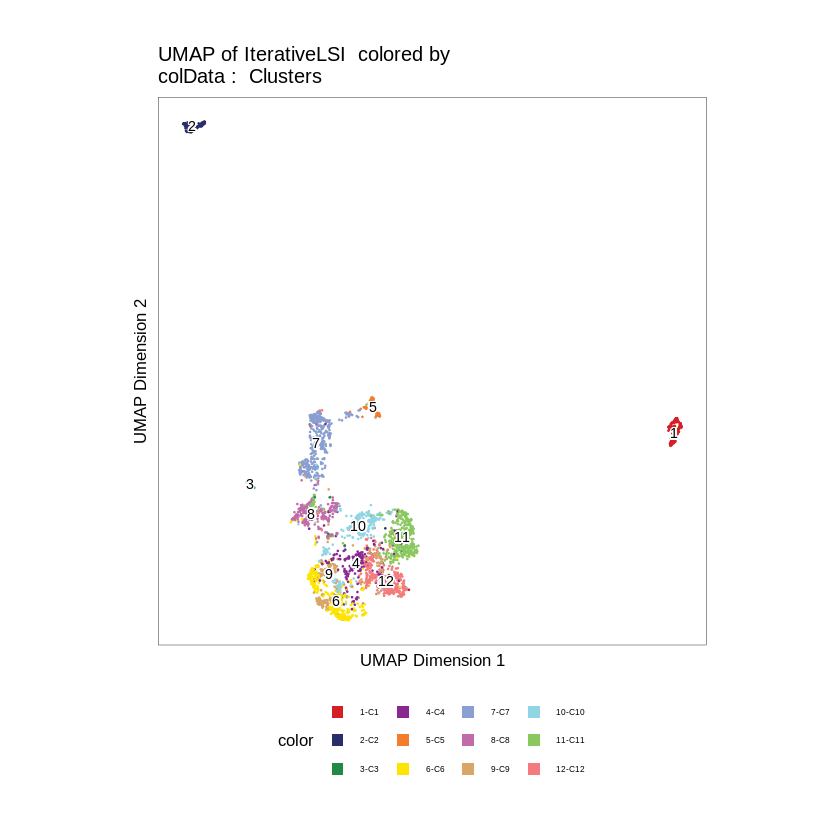

In [238]:
plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "Clusters", embedding = "UMAP")

In [272]:
table(ArchRProject.filt@cellColData$Clusters)


 C1 C10 C11 C12  C2  C3  C4  C5  C6  C7  C8  C9 
183 314 436 340 148  69 209 107 367 458 252 222 

In [248]:
markersGS <- getMarkerFeatures(
    ArchRProj = ArchRProject.filt, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-35161a9c50f5-Date-2021-11-23_Time-17-55-19.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2021-11-23 17:55:19 : Matching Known Biases, 0.001 mins elapsed.

###########
2021-11-23 17:57:22 : Completed Pairwise Tests, 2.053 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-35161a9c50f5-Date-2021-11-23_Time-17-55-19.log



In [249]:
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.01 & Log2FC >= 1.25")

In [261]:
head(markerList[[11]])

DataFrame with 2 rows and 9 columns
      seqnames    start      end  strand      name     idx    Log2FC        FDR
         <Rle>  <array>  <array> <array>   <array> <array> <numeric>  <numeric>
13581     chr3 64559818 64537561       2    Vmn2r6     283   1.28179 0.00739500
9897     chr18 10782976 10782909       2 Mir133a-1      41   1.75482 0.00752208
       MeanDiff
      <numeric>
13581 0.0324548
9897  0.1271197

In [262]:
markerGenes = c('Cubn', 'Hba-x', 'Kdr', 'Mir679', 'Vmn2r6')
heatmapGS <- markerHeatmap(
  seMarker = markersGS, 
  cutOff = "FDR <= 0.01 & Log2FC >= 1.25", 
  labelMarkers = markerGenes,
  transpose = TRUE
)


Warning message:
“'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated")”
ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-351664492484-Date-2021-11-23_Time-17-59-27.log
If there is an issue, please report to github with logFile!

Printing Top Marker Genes:

C1:

	Mrpl15, Lypla1, Mcmdc2, Xkr9, Terf1, Gsta3, Gm4956, Khdc1a, Khdc1c, Khdc1b, Bag2, Mir6898, Slc40a1, 1700019D03Rik, Gm20257

C2:

	Mir30c-2, Tmem131, Snord70, Kif1a, Acmsd, Mgst3, Ackr1, Spta1, Pycr2, Wdr26, Gm2061, Slc30a10, Cd46, Gm33619, Taar7b

C3:

	Fam124b, Selp, Fam71a, Cd34, Gm17745, Olfr1378, Gas7, Atp2a3, P2rx1, 2410003L11Rik, 5033406O09Rik, Mir874, Ctla2a, Zfp366, Sox7

C4:

	Mrpl15, Lypla1, Mcmdc2, Xkr9, Terf1, Gsta3, Gm4956, Khdc1a, Khdc1c, Khdc1b, Mir30c-2, Bag2, Mir6898, Tmem131, Slc40a1

C5:

	Mir466m, Mir669f, Mir669e, Mir669b, Mir669d, Mir669l, Mir669d-2, Mir297a-2, Mir467c, Mir466b-1, Mir669a-3, Mir669k, Mir467a-1, Mir466b-8, Mir669a-1

C6:

	4930405J17Rik, Mir135a-2, Gm29

[1] "Cubn"   "Hba-x"  "Kdr"    "Mir679" "Vmn2r6"


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-351664492484-Date-2021-11-23_Time-17-59-27.log



In [267]:
p = ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [268]:
      outfile <-  outfile <- paste0(args$outdir, 'heatmap.pdf')

      pdf(outfile, width=7, height=5)
      print(p)
      dev.off()

png 
  2

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3516346d355d-Date-2021-11-23_Time-18-07-00.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2021-11-23 18:07:00 : 

1 


Plotting Embedding

1 
2 
3 
4 
5 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3516346d355d-Date-2021-11-23_Time-18-07-00.log

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


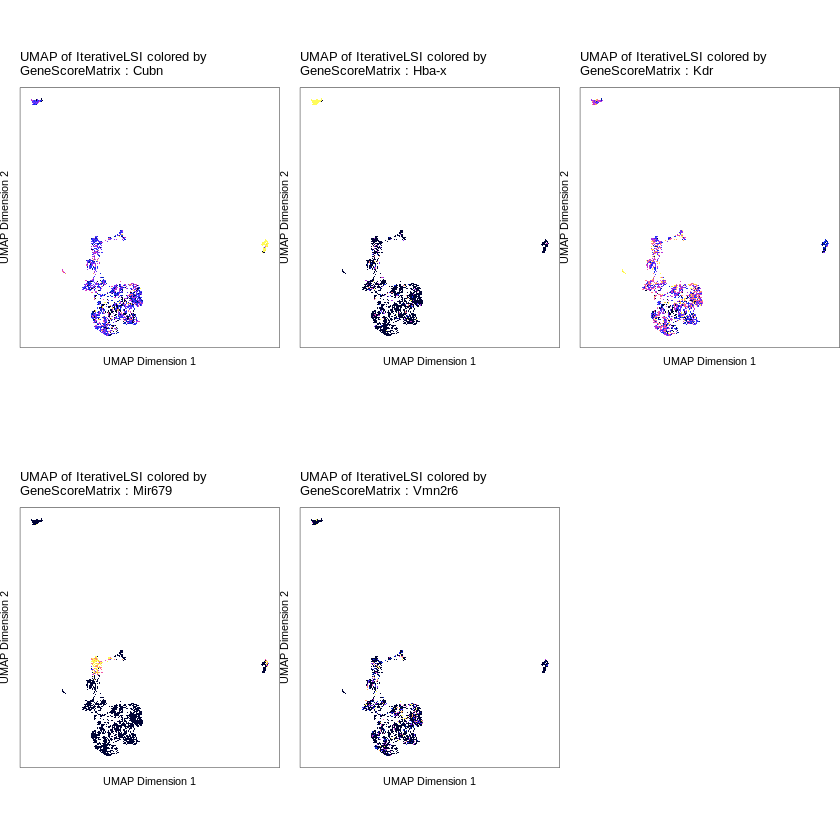

In [276]:
p <- plotEmbedding(
    ArchRProj = ArchRProject.filt, 
    colorBy = "GeneScoreMatrix", 
    name = markerGenes, 
    embedding = "UMAP",
    quantCut = c(0.01, 0.95),
    imputeWeights = NULL
)

p2 = lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

In [277]:
ArchRProject.filt <- addImputeWeights(ArchRProject.filt)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-351675e8fabd-Date-2021-11-23_Time-18-07-06.log
If there is an issue, please report to github with logFile!

2021-11-23 18:07:07 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

Filtering 2 dims correlated > 0.75 to log10(depth + 1)



ERROR: Error in dir.create(file.path(getOutputDirectory(ArchRProj), "ImputeWeights"), : invalid 'path' argument


In [285]:
saveArchRProject(ArchRProject.filt, outputDirectory = '/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/dimensionality_reduction/')

ERROR: Error in path.expand(path): invalid 'path' argument


#### archR_dimensionality_reduction.R

In [190]:
args$outdir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/dimensionality_reduction"

In [198]:
## START TEST ##
args <- list()
args$metadata <- paste0(io$archR.directory,"sample_metadata.txt.gz")
args$nfeatures <- 15000
args$matrix <- "GeneScoreMatrix"
args$ndims <- 25
args$seed <- 42
args$n_neighbors <- 25
args$min_dist <- 0.3
args$colour_by <- c("sample")
args$vars_to_regress <- NULL #c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- paste0(io$basedir,"/dimensionality_reduction")
args$remove_ExE_cells = FALSE
## END TEST ##


#####################
## Define settings ##
#####################

# source(here::here("settings.R"))
# source(here::here("utils.R"))

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

# if (args$stages[1]=="all") {
#   args$stages <- opts$stages
# } else {
#   stopifnot(args$stages%in%opts$stages)
# }


##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% #.[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE] %>%  #& stage%in%args$stages] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]

#stopifnot(args$colour_by %in% colnames(sample_metadata))

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

table(sample_metadata$stage)
table(sample_metadata$celltype.mapped_mnn)

########################
## Load ArchR project ##
########################

source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]
# ArchRProject.filt@sampleColData <- ArchRProject.filt@sampleColData[args$samples,,drop=F]

###################
## Sanity checks ##
###################

stopifnot(args$matrix %in% getAvailableMatrices(ArchRProject))

if (length(args$batch.variable)>0) {
  stopifnot(args$batch.variable%in%colnames(sample_metadata))
  if (length(unique(sample_metadata[[args$batch.variable]]))==1) {
    message(sprintf("There is a single level for %s, no batch correction applied",args$batch.variable))
    args$batch.variable <- NULL
  } else {
    library(batchelor)
  }
}

if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
}

###########################
## Update ArchR metadata ##
###########################

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
for (i in args$colour_by) {
  ArchRProject.filt <- addCellColData(
    ArchRProject.filt,
    data = sample_metadata.to.archr[[i]],
    name = i,
    cells = rownames(sample_metadata.to.archr),
    force = TRUE
  )
  print(table(getCellColData(ArchRProject.filt,i)[[1]]))
}


#######################
## Feature selection ##
#######################

# if (args$matrix=="PeakMatrix_filt") {
  
#   # Load peak variability estimates
#   peak.variability.dt <- fread(io$archR.peak.variability)
  
#   # Define highly variable peaks
#   peaks <- peak.variability.dt %>% 
#     .[,peak:=sub("_",":",peak)] %>% .[,peak:=sub("_","-",peak)] %>%
#     setorder(-variance_pseudobulk) %>% 
#     head(n=args$nfeatures) %>% 
#     .$peak
  
#   # Subset peaks in the ArchR object
#   names(ArchRProject.filt@peakSet) <- sprintf("%s:%s-%s",seqnames(ArchRProject.filt@peakSet), start(ArchRProject.filt@peakSet), end(ArchRProject.filt@peakSet))
#   ArchRProject.filt@peakSet[peaks,] <- ArchRProject.filt@peakSet[peaks,]
  
#   ArchRProject.filt <- addFeatureMatrix(
#     input = ArchRProject.filt,
#     features = ArchRProject.filt@peakSet,
#     matrixName = "PeakMatrix_filt",
#     binarize = TRUE
#   )
  
# }

###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  # clusterParams = list(
  #  resolution = opts$lsi.cluster.resolution, 
  #  sampleCells = 10000, 
  #  n.start = 10
  # ), 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE,
  outDir = args$outdir
)

# Correlation between latent dimensions and number of peaks
# cor(getReducedDims(ArchRProject.filt, "IterativeLSI"),ArchRProject.filt$nFrags)[,1] %>% abs %>% sort(decreasing = T)

############################
## LSI + Batch correction ##
############################

if (length(args$batch.variable)>0) {
  print(sprintf("Applying %s batch correction for variable: %s", args$batch.method, args$batch.variable))
  outfile <- sprintf("%s/lsi_%s_nfeatures%d_dims%d_%sbatchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, args$batch.method, paste(args$batch.variable,collapse="-"))
  
  # Harmony
  if (args$batch.method=="Harmony") {
    ArchRProject.filt <- addHarmony(
      ArchRProj = ArchRProject.filt,
      reducedDims = "IterativeLSI",
      name = "IterativeLSI_Harmony",
      groupBy = "stage",
      force = TRUE
    )
    lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI_Harmony") %>% round(3) %>% 
      as.data.table(keep.rownames = T) %>% setnames("rn","cell")

  } else {
    stop("Batch correction method not recognised")
  }

} else {
  outfile <- sprintf("%s/lsi_%s_nfeatures%d_ndims%d.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims)
  lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}

# Save LSI coordinates
fwrite(lsi.dt, outfile)

##########
## UMAP ##
##########

# i <- args$n_neighbors[1]
# j <- args$min_dist[1]
for (i in args$n_neighbors) {
  for (j in args$min_dist) {
    
    # Define the latent space to run UMAP on
    if (length(opts$batch.correction)>0) {
      if (args$batch.method=="Harmony") {
        dimred <- "IterativeLSI_Harmony"
      } else if  (args$batch.method=="MNN") {
        dimred <- "IterativeLSI_MNN"
      } else {
        stop("Batch correction method not recognised")
      }
    } else {
      dimred <- "IterativeLSI"
    }
    
    # Run UMAP
    ArchRProject.filt <- addUMAP(
      ArchRProj = ArchRProject.filt, 
      reducedDims = dimred,
      name = "UMAP",
      metric = "cosine",
      nNeighbors = i, 
      minDist = j, 
      seed = args$seed,
      saveModel = FALSE,
      force = TRUE
    )
    
    # Fetch UMAP coordinates
    umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
      round(2) %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))
    
    # Save UMAP coordinates
    # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j)
    outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims)
    fwrite(umap.dt, outfile)

    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    
    for (k in args$colour_by) {

      # log10 large numeric values
      if (is.numeric(to.plot[[k]])) {
        if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
          to.plot[[k]] <- log10(to.plot[[k]]+1)
          to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
        }
      }
      
      p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", fill=k)) +
        geom_point(size=1.5, shape=21, stroke=0.05) +
        # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
        theme_classic() +
        ggplot_theme_NoAxes()
      
#       # Define colormap
#       if (is.numeric(to.plot[[j]])) {
#         p <- p + scale_fill_gradientn(colours = terrain.colors(10))
#       }

#       if (grepl("celltype",k)) {
#         p <- p + scale_fill_manual(values=opts$celltype.colors) +
#           theme(
#             legend.position="none",
#             legend.title=element_blank()
#           )
#       }
      
#       if (grepl("stage",i)) {
#         p <- p + scale_fill_manual(values=opts$stage.colors) +
#           theme(
#             legend.position="none",
#             legend.title=element_blank()
#           )
#       }
      # Save UMAP plot
      # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j, k)
      outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, k)
      pdf(outfile, width=7, height=5)
      print(p)
      dev.off()
    }
    
  }
}


E8.75 
 3105 

< table of extent 0 >

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__


E8.75_rep1 
      3105 


Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-35165fb3da22-Date-2021-11-23_Time-17-26-08.log
If there is an issue, please report to github with logFile!

2021-11-23 17:26:09 : Computing Total Across All Features, 0 mins elapsed.

2021-11-23 17:26:09 : Computing Top Features, 0.007 mins elapsed.

###########
2021-11-23 17:26:10 : Running LSI (1 of 2) on Top Features, 0.021 mins elapsed.
###########

2021-11-23 17:26:10 : Creating Partial Matrix, 0.022 mins elapsed.

2021-11-23 17:26:27 : Computing LSI, 0.302 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2021-11-23 17:26:59 : Identifying Clusters, 0.837 mins elapsed.

Warning message:
“The following arguments are not used: row.names”
2021-11-23 17:27:18 : Identified 6 Clusters, 1.151 mins elapsed.

2021-11-23 17:27:18 : Creating Cluster Matrix on the total Group Features, 1.151 mins elapsed.

Warning message in mclapply(..., mc.cores = threads, mc.preschedule = preschedule):
“3 parallel f


************************************************************
2021-11-23 17:28:11 : ERROR Found in .identifyVarFeatures for  
LogFile = ArchRLogs/ArchR-addIterativeLSI-35165fb3da22-Date-2021-11-23_Time-17-26-08.log

<simpleError in mat[rownames(featureDF), , drop = FALSE]: subscript out of bounds>

************************************************************



ERROR: Error in .logError(e, fn = ".identifyVarFeatures", info = "", errorList = errorList, : Exiting See Error Above


#### 1_archR_add_GroupCoverage.R

In [167]:
# https://www.ArchRProject.com/bookdown/how-does-archr-make-pseudo-bulk-replicates.html

########################
## Load ArchR project ##
########################

source("/rds/project/rds-SDzz0CATGms/users/bt392/ArchR_practice/gastrulation/load_archR_project.R")


#####################
## Define settings ##
#####################

# I/O
# io$metadata <- paste0(io$basedir,"/results/atac/archR/celltype_assignment/sample_metadata_after_archR.txt.gz")
# io$metadata <- paste0(io$basedir,"/sample_metadata.txt.gz")

# Options
opts$samples <- c(
#   "E7.5_rep1",
#   "E7.5_rep2",
#   "E8.0_rep1",
#   "E8.0_rep2",
#   "E8.5_rep1",
#   "E8.5_rep2"
    "E8.75_rep1"
)

# opts$to.merge <- c(
#   "Erythroid3" = "Erythroid",
#   "Erythroid2" = "Erythroid",
#   "Erythroid1" = "Erythroid",
#   "Blood_progenitors_1" = "Blood_progenitors",
#   "Blood_progenitors_2" = "Blood_progenitors"
#   # "Intermediate_mesoderm" = "Mixed_mesoderm",
#   # "Paraxial_mesoderm" = "Mixed_mesoderm",
#   # "Nascent_mesoderm" = "Mixed_mesoderm",
#   # "Pharyngeal_mesoderm" = "Mixed_mesoderm"
#   # "Visceral_endoderm" = "ExE_endoderm"
# )

opts$remove.small.lineages <- TRUE

########################
## Load cell metadata ##
########################

sample_metadata <- fread(io$metadata) %>%
   .[,pass_atacQC:=TSSEnrichment_atac>=opts$min.TSSEnrichment & log2(nFrags_atac)>=opts$min.log_nFrags & BlacklistRatio_atac<=opts$max.BlacklistRatio] %>%
   .[is.na(pass_atacQC),pass_atacQC:=FALSE] %>% 
    .[pass_atacQC==TRUE & sample%in%opts$samples]
 # .[pass_atacQC==TRUE & !is.na(celltype.predicted) & sample%in%opts$samples] %>%
 # .[,celltype.predicted:=stringr::str_replace_all(celltype.predicted,opts$to.merge)]
sample_metadata$celltype.predicted = c(rep('Celltype1', 1000),rep('Celltype2', 1000), rep('Celltype3', nrow(sample_metadata)-2000))

if (opts$remove.small.lineages) {
  opts$min.cells <- 50
  sample_metadata <- sample_metadata %>%
    .[,N:=.N,by=c("celltype.predicted")] %>% .[N>opts$min.cells] %>% .[,N:=NULL]
}

##################
## Subset ArchR ##
##################

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

# Update archR metadata
sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(sample_metadata.to.archr$TSSEnrichment_atac == getCellColData(ArchRProject.filt,"TSSEnrichment")[[1]]))

ArchRProject.filt <- addCellColData(
  ArchRProject.filt,
  data = sample_metadata.to.archr[["celltype.predicted"]], 
  name = "celltype.predicted",
  cells = rownames(sample_metadata.to.archr),
  force = TRUE
)

# print cell numbers
table(getCellColData(ArchRProject.filt,"Sample")[[1]])
table(getCellColData(ArchRProject.filt,"celltype.predicted")[[1]])

#########################
## Add Group Coverages ##
#########################

# Check if group Coverages already exist
ArchRProject.filt@projectMetadata$GroupCoverages

# This function will merge cells within each designated cell group for the generation of pseudo-bulk replicates 
# and then merge these replicates into a single insertion coverage file.
# Output: creates files in archR/GroupCoverages/celltype: [X]._.Rep[Y].insertions.coverage.h5
ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, groupBy = "celltype.predicted", force = TRUE)

##########
## Save ##
##########

io$archR.projectMetadata <- paste0(io$archR.directory,"/projectMetadata.rds")
saveRDS(ArchRProject.filt@projectMetadata, io$archR.projectMetadata)

# saveArchRProject(ArchRProject.filt)

Setting default genome to Mm10.

Setting default number of Parallel threads to 8.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__


E8.75_rep1 
      3078 


Celltype1 Celltype2 Celltype3 
     1000      1000      1078 

NULL

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-35165a81da1b-Date-2021-11-23_Time-16-59-30.log
If there is an issue, please report to github with logFile!



ERROR: Error in `[[<-`(`*tmp*`, name, value = new("SimpleList", listData = list(), : 0 elements in value to replace 3247 elements


In [174]:
ArchRProject@projectMetadata = ArchRProject.filt@cellColData

In [175]:

ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, groupBy = "celltype.predicted", force = TRUE)

##########
## Save ##
##########

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-351620586a12-Date-2021-11-23_Time-17-02-29.log
If there is an issue, please report to github with logFile!



ERROR: Error in `[[<-`(`*tmp*`, name, value = new("SimpleList", listData = list(), : 0 elements in value to replace 3247 elements
